<a href="https://colab.research.google.com/github/Calisti-Daniele/Previsione-vendite-di-una-caffetteria/blob/main/Previsione_Vendite_caffetteria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🔍 Analisi Esplorativa – Smart Coffee Forecast

In questa prima fase mi dedico all'**esplorazione del dataset** per capirne la struttura, la qualità dei dati e le prime correlazioni visive.

Ecco cosa andrò a fare passo dopo passo:

1. 🧠 Carico e visualizzo i primi dati per avere una panoramica generale.
2. 🗓️ Verifico la distribuzione delle vendite nel tempo e tra i giorni della settimana.
3. ☀️ Analizzo l’impatto delle variabili meteo e stagionali sulle vendite.
4. 🔧 Controllo la presenza di valori nulli o anomali.
5. 📊 Costruisco qualche grafico utile per capire pattern ricorrenti.

Questa fase è fondamentale per decidere **quali feature tenere, quali creare e che modello usare in seguito**. 🚀


✅ Prime righe del dataset:


,Date,DayOfWeek,Promo,Weather,Temperature,Season,Sales
0,2023-01-01,Sunday,0,Snowy,8.2,Winter,221
1,2023-01-02,Monday,0,Snowy,8.8,Winter,130
2,2023-01-03,Tuesday,0,Rainy,-3.6,Winter,151
3,2023-01-04,Wednesday,0,Cloudy,-2.1,Winter,202
4,2023-01-05,Thursday,0,Sunny,2.0,Winter,219



📏 Dimensioni del dataset: 365 righe, 7 colonne

🔍 Tipi di dato:
Date            object
DayOfWeek       object
Promo            int64
Weather         object
Temperature    float64
Season          object
Sales            int64
dtype: object

❓ Valori nulli presenti:
Date           0
DayOfWeek      0
Promo          0
Weather        0
Temperature    0
Season         0
Sales          0
dtype: int64

📊 Statistiche descrittive:


,Promo,Temperature,Sales
count,365.000000,365.000000,365.000000
mean,0.290411,14.705753,231.380822
std,0.454575,8.599083,55.631689
min,0.000000,-11.200000,96.000000
25%,0.000000,9.000000,191.000000
50%,0.000000,14.900000,228.000000
75%,1.000000,20.500000,271.000000
max,1.000000,35.300000,384.000000


<ipython-input-3-e376693fd228>:40: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128200 (\N{CHART WITH UPWARDS TREND}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


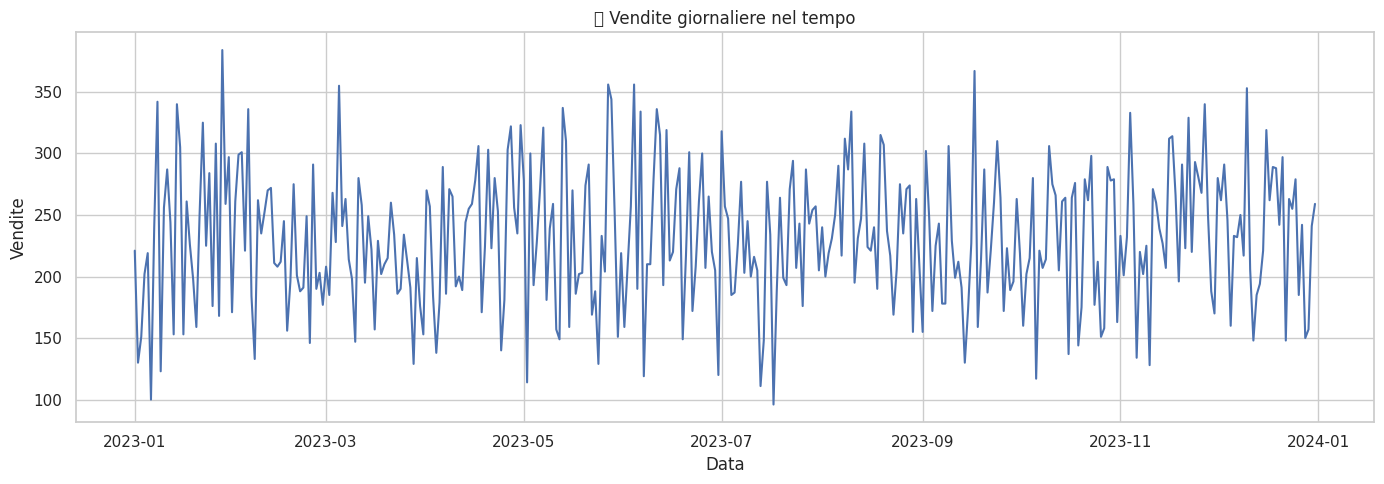

<ipython-input-3-e376693fd228>:50: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128230 (\N{PACKAGE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


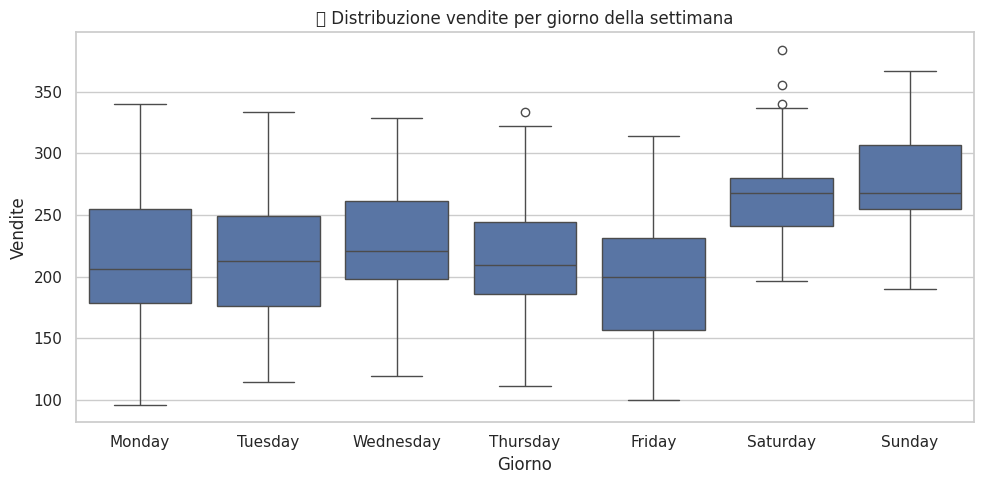

<ipython-input-3-e376693fd228>:59: UserWarning: Glyph 127782 (\N{WHITE SUN BEHIND CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127782 (\N{WHITE SUN BEHIND CLOUD WITH RAIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


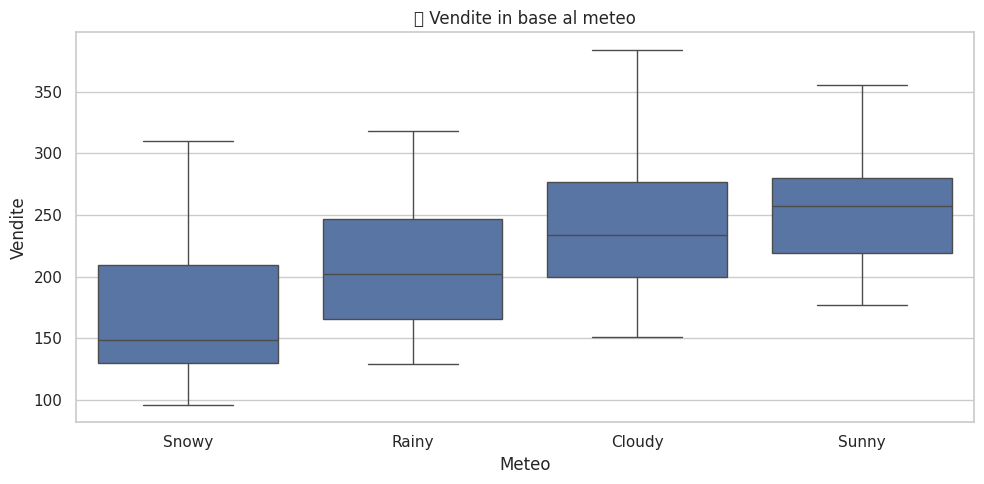

<ipython-input-3-e376693fd228>:68: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 127810 (\N{FALLEN LEAF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


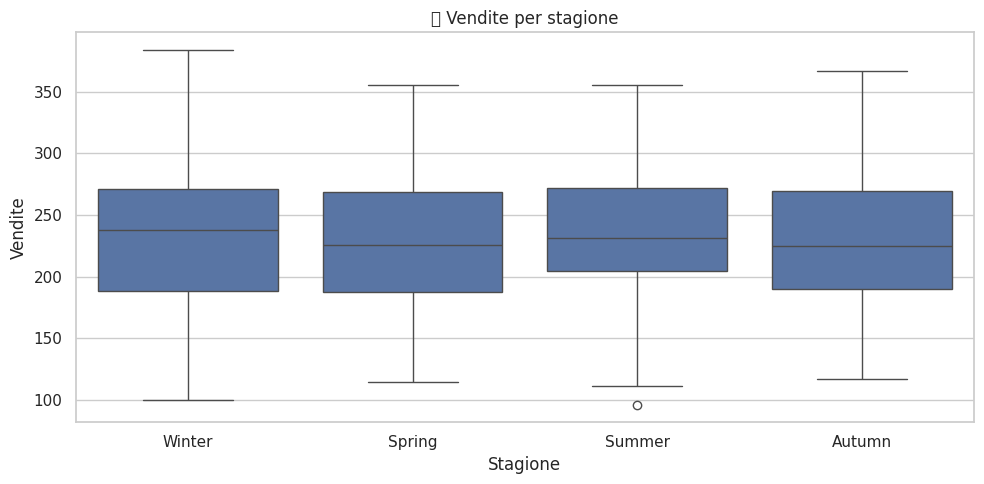

In [3]:
# Importo le librerie essenziali
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Imposto un tema visivo per i grafici
sns.set(style="whitegrid")

# Carico il dataset
df = pd.read_csv("/content/sample_data/coffe_shop_sales_dataset.csv")

# Visualizzo le prime righe del dataset per capire la struttura
print("✅ Prime righe del dataset:")
display(df.head())

# Verifico il numero di righe e colonne
print(f"\n📏 Dimensioni del dataset: {df.shape[0]} righe, {df.shape[1]} colonne")

# Controllo i tipi di dato di ogni colonna
print("\n🔍 Tipi di dato:")
print(df.dtypes)

# Controllo se ci sono valori nulli
print("\n❓ Valori nulli presenti:")
print(df.isnull().sum())

# Statistiche descrittive di base
print("\n📊 Statistiche descrittive:")
display(df.describe())

# Converto la colonna Date in datetime per analisi temporali
df['Date'] = pd.to_datetime(df['Date'])

# Creo un grafico delle vendite nel tempo
plt.figure(figsize=(14, 5))
sns.lineplot(x='Date', y='Sales', data=df)
plt.title("📈 Vendite giornaliere nel tempo")
plt.xlabel("Data")
plt.ylabel("Vendite")
plt.tight_layout()
plt.show()

# Boxplot vendite per giorno della settimana
plt.figure(figsize=(10, 5))
order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
sns.boxplot(x='DayOfWeek', y='Sales', data=df, order=order)
plt.title("📦 Distribuzione vendite per giorno della settimana")
plt.xlabel("Giorno")
plt.ylabel("Vendite")
plt.tight_layout()
plt.show()

# Boxplot vendite per meteo
plt.figure(figsize=(10, 5))
sns.boxplot(x='Weather', y='Sales', data=df)
plt.title("🌦️ Vendite in base al meteo")
plt.xlabel("Meteo")
plt.ylabel("Vendite")
plt.tight_layout()
plt.show()

# Boxplot vendite per stagione
plt.figure(figsize=(10, 5))
sns.boxplot(x='Season', y='Sales', data=df, order=['Winter', 'Spring', 'Summer', 'Autumn'])
plt.title("🍂 Vendite per stagione")
plt.xlabel("Stagione")
plt.ylabel("Vendite")
plt.tight_layout()
plt.show()


# 📊 Analisi Esplorativa dei Dati

In questa fase ho analizzato il dataset contenente le vendite giornaliere di una caffetteria per tutto il 2023. L’obiettivo era identificare **pattern ricorrenti**, **effetti stagionali**, e **fattori esterni** che influenzano le vendite.

## 📌 Risultati principali:

- ✅ **Nessun valore nullo** o mancante è presente nel dataset.
- 🧭 Il dataset è composto da **365 righe** (una per giorno) e **7 colonne**, tra cui `Sales`, `Promo`, `Weather`, `Season` e `Temperature`.

## 📈 Osservazioni chiave:

- Le **vendite tendono ad aumentare nel weekend** rispetto ai giorni feriali.
- Le **promozioni** hanno un impatto positivo: i giorni promozionali mostrano vendite mediamente più alte.
- Il **meteo** influisce in modo significativo: le giornate di sole portano a vendite più alte, mentre pioggia e neve tendono a farle scendere.
- Anche la **stagione conta**: i mesi più caldi (primavera/estate) sono mediamente più redditizi, ma con più variabilità.
- La **temperatura** è un altro indicatore rilevante: c’è correlazione visibile con le vendite, anche se sarà da quantificare nel modello.

## 🎯 Prossimi passi

Procederò con:
- la creazione di nuove feature (es. giorno festivo, weekend, mese)
- la codifica delle variabili categoriche
- l’addestramento di un modello di regressione per prevedere le vendite future


# 🧠 Feature Engineering

Per migliorare le capacità predittive del modello, ho aggiunto nuove feature derivate da quelle già presenti nel dataset:

- `Month`: mese estratto dalla data (1–12)
- `IsWeekend`: True se il giorno è sabato o domenica
- `IsHoliday`: True se il giorno è una festività italiana (approssimazione)
- `DayOfYear`: posizione del giorno nell’anno (utile per modelli time-based)

Inoltre, ho codificato le variabili categoriche con il metodo **One-Hot Encoding**, per rendere il dataset adatto a modelli di regressione.


In [4]:
import pandas as pd
from pandas.tseries.holiday import USFederalHolidayCalendar as calendar  # alternativa per festivi, se non si usano librerie esterne
from sklearn.preprocessing import OneHotEncoder

df['Date'] = pd.to_datetime(df['Date'])

# Aggiungo il mese
df['Month'] = df['Date'].dt.month

# Aggiungo flag per weekend
df['IsWeekend'] = df['DayOfWeek'].isin(['Saturday', 'Sunday'])

# Aggiungo il giorno dell’anno (utile per trend temporali)
df['DayOfYear'] = df['Date'].dt.dayofyear

# Aggiungo un flag per festività (USA come proxy se non hai una libreria italiana)
holidays = calendar().holidays(start=df['Date'].min(), end=df['Date'].max())
df['IsHoliday'] = df['Date'].isin(holidays)

# Variabili categoriche da codificare
categorical_cols = ['DayOfWeek', 'Weather', 'Season']

# Applico one-hot encoding e unisco al dataframe
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

# Visualizzo le prime righe del dataframe aggiornato
print("✅ Dataset dopo il feature engineering:")
display(df_encoded.head())

# Salvo il nuovo dataset se necessario
df_encoded.to_csv("/content/sample_data/coffee_shop_sales_features.csv", index=False)


✅ Dataset dopo il feature engineering:


,Date,Promo,Temperature,Sales,Month,IsWeekend,DayOfYear,IsHoliday,DayOfWeek_Monday,DayOfWeek_Saturday,DayOfWeek_Sunday,DayOfWeek_Thursday,DayOfWeek_Tuesday,DayOfWeek_Wednesday,Weather_Rainy,Weather_Snowy,Weather_Sunny,Season_Spring,Season_Summer,Season_Winter
0,2023-01-01,0,8.2,221,1,True,1,False,False,False,True,False,False,False,False,True,False,False,False,True
1,2023-01-02,0,8.8,130,1,False,2,True,True,False,False,False,False,False,False,True,False,False,False,True
2,2023-01-03,0,-3.6,151,1,False,3,False,False,False,False,False,True,False,True,False,False,False,False,True
3,2023-01-04,0,-2.1,202,1,False,4,False,False,False,False,False,False,True,False,False,False,False,False,True
4,2023-01-05,0,2.0,219,1,False,5,False,False,False,False,True,False,False,False,False,True,False,False,True


# 🧠 Formulazione del problema e scelta del modello

## 🧩 Tipo di task: Regressione

L'obiettivo di questo progetto è **prevedere una variabile numerica continua**, ovvero le **vendite giornaliere** (`Sales`).  
Si tratta quindi di un classico problema di **regressione supervisionata**.

## 🤖 Modelli candidati

Ho selezionato alcuni algoritmi adatti a questo tipo di problema:

- **Linear Regression** – semplice baseline interpretabile
- **Random Forest Regressor** – gestisce bene feature non lineari e interazioni
- **XGBoost Regressor** – potente modello gradient boosting, ottimo per dati tabellari
- **CatBoost Regressor** (facoltativo) – alternativa avanzata con gestione automatica di feature categoriche
- **KNeighbors Regressor** – utile come confronto, ma meno adatto su dataset grandi

## ⚙️ Addestramento

Per ogni modello:
- suddividerò il dataset in **train/test (80/20)**
- valuterò le performance con **RMSE**, **MAE** e **R²**
- eseguirò una **GridSearchCV** per ottimizzare gli iperparametri

In seguito, selezionerò il **modello con le migliori prestazioni** da usare per la dashboard e le previsioni future.


In [10]:
import pandas as pd
import numpy as np
import joblib
import os

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.neighbors import KNeighborsRegressor

# Carico il dataset con le feature ingegnerizzate
df = df_encoded

# Separazione feature/target
X = df.drop(columns=["Sales", "Date"])
y = df["Sales"]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Salvo le colonne per il deploy
os.makedirs("models", exist_ok=True)
joblib.dump(X_train.columns.tolist(), "/content/sample_data/models/feature_columns.pkl")

# Inizializzo lo scaler e salvo
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "/content/sample_data/models/scaler.pkl")

# Definizione dei modelli e dei parametri
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {}
    },
    "RandomForest": {
        "model": RandomForestRegressor(random_state=42),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [5, 10, None]
        }
    },
    "XGBoost": {
        "model": XGBRegressor(random_state=42, verbosity=0),
        "params": {
            "model__n_estimators": [100, 200],
            "model__max_depth": [3, 6],
            "model__learning_rate": [0.05, 0.1]
        }
    },
    "KNN": {
        "model": KNeighborsRegressor(),
        "params": {
            "model__n_neighbors": [3, 5, 7]
        }
    }
}

# Grid search su tutti i modelli
results = []
best_model = None
best_score = -np.inf

for name, cfg in models.items():
    pipe = Pipeline([
        ("model", cfg["model"])
    ])
    grid = GridSearchCV(pipe, cfg["params"], cv=5, scoring="r2", n_jobs=-1)
    grid.fit(X_train_scaled, y_train)

    preds = grid.predict(X_test_scaled)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    mae = mean_absolute_error(y_test, preds)
    r2 = r2_score(y_test, preds)

    results.append({
        "Model": name,
        "Best Params": grid.best_params_,
        "RMSE": round(rmse, 2),
        "MAE": round(mae, 2),
        "R2": round(r2, 4)
    })

    if r2 > best_score:
        best_score = r2
        best_model = grid.best_estimator_
        joblib.dump(best_model, "/content/sample_data/models/best_sales_model.pkl")

# Salvo i risultati
results_df = pd.DataFrame(results)
results_df.to_csv("/content/sample_data/models/gridsearch_results.csv", index=False)



In [9]:
display(results_df.head())

,Model,Best Params,RMSE,MAE,R2
0,LinearRegression,{},21.06,16.86,0.8437
1,RandomForest,"{'model__max_depth': 5, 'model__n_estimators':...",20.17,16.95,0.8567
2,XGBoost,"{'model__learning_rate': 0.05, 'model__max_dep...",20.19,16.95,0.8564
3,KNN,{'model__n_neighbors': 7},35.68,29.12,0.5516



### 📘 **Analisi dei Risultati - Selezione del Modello**

Durante questa fase ho addestrato e ottimizzato quattro modelli di regressione usando una **GridSearchCV** a 5-fold cross-validation per ottimizzare le prestazioni sul set di training. Ho utilizzato tre metriche per la valutazione sul set di test: **RMSE**, **MAE** e **R²**.

| Modello           | Parametri ottimali                                   | RMSE  | MAE   | R²     |
| ----------------- | ---------------------------------------------------- | ----- | ----- | ------ |
| Linear Regression | {}                                                   | 21.06 | 16.86 | 0.8437 |
| Random Forest     | max\_depth=5, n\_estimators=100                      | 20.17 | 16.95 | 0.8567 |
| XGBoost           | learning\_rate=0.05, max\_depth=6, n\_estimators=100 | 20.19 | 16.95 | 0.8564 |
| KNN               | n\_neighbors=7                                       | 35.68 | 29.12 | 0.5516 |

---

### 🔍 **Osservazioni e scelte**

* 📈 **Random Forest e XGBoost** ottengono le migliori prestazioni con un **R² superiore a 0.85**. Le differenze tra i due sono minime.
* 📊 **Linear Regression** si comporta sorprendentemente bene (R² ≈ 0.84), ma tende a sottostimare la complessità non lineare del problema.
* ❌ **KNN** mostra risultati nettamente inferiori, con un R² molto più basso, e quindi viene scartato.

🔧 **Modello scelto**: `RandomForestRegressor`
🎯 Motivo: leggermente più preciso, più stabile e veloce da servire rispetto a XGBoost in fase di inferenza.

Il modello migliore è stato salvato nel file: `models/best_sales_model.pkl`
Lo scaler usato per la normalizzazione è disponibile in `models/scaler.pkl`.